**Đọc dataset**

In [1]:
!pip install -q kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd

file_path = "go_emotions_dataset.csv"


df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "shivamb/go-emotions-google-emotions-dataset",
    file_path
)

# Khai báo cấu trúc hệ thống phân loại 28 nhãn chuẩn của Google
emotion_labels = [
    "admiration", "amusement", "anger", "annoyance", "approval", "caring",
    "confusion", "curiosity", "desire", "disappointment", "disapproval",
    "disgust", "embarrassment", "excitement", "fear", "gratitude", "grief",
    "joy", "love", "nervousness", "optimism", "pride", "realization",
    "relief", "remorse", "sadness", "surprise", "neutral"
]



/tmp/ipykernel_581/2057014050.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 8.68M/8.68M [00:00<00:00, 52.8MB/s]

Extracting zip of go_emotions_dataset.csv...


**Gom cụm**

In [2]:
# Gom cụm các rater đánh giá cùng một câu bình luận lại với nhau
grouped = df.groupby(['id', 'text'])[emotion_labels].sum().reset_index()
print(f"Số lượng câu bình luận độc nhất sau khi gom cụm: {len(grouped)} câu.")

# Nhãn cảm xúc nào được ít nhất 2 chuyên gia chọn mới tính là 1, dưới 2 phiếu bầu sẽ bị hủy (= 0)
for col in emotion_labels:
    grouped[col] = (grouped[col] >= 2).astype(int)

# Tính tổng số nhãn được kích hoạt cho mỗi câu
grouped['has_label'] = grouped[emotion_labels].sum(axis=1)
# Chỉ giữ lại các câu có ít nhất 1 nhãn cảm xúc đạt sự đồng thuận từ 2 người trở lên
grouped_clean = grouped[grouped['has_label'] > 0].drop(columns=['has_label'])

print(f"🔹 Số lượng câu bình luận sạch thu được: {len(grouped_clean)} câu.")

# Xem thử 3 dòng đầu tiên sau khi làm sạch
grouped_clean.head(3)

Số lượng câu bình luận độc nhất sau khi gom cụm: 58011 câu.
🔹 Số lượng câu bình luận sạch thu được: 54263 câu.


,id,text,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,eczazk6,Fast as [NAME] will carry me. Seriously uptown...,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,eczb07q,You blew it. They played you like a fiddle.,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,eczb4bm,TL;DR No more Superbowls for [NAME]. Get ready...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


**Làm sạch**

In [3]:
import re
import unicodedata
import nltk
from nltk.stem import WordNetLemmatizer

# Tải thư viện cần thiết (thêm quiet=True để giảm log rác trên màn hình)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

lemmatizer = WordNetLemmatizer()

def clean_text_for_cnn(text, use_lemmatization=False):
    # 1. Tránh lỗi crash nếu dữ liệu bị trống (NaN)
    if not isinstance(text, str):
        return ""

    # 2. Đưa về chữ thường
    text = text.lower()

    # 3. Đồng bộ hóa "dấu nháy" và xử lý Unicode
    text = re.sub(r"[’‘`´]", "'", text)
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8')

    # 4. Khai triển từ viết tắt (RẤT QUAN TRỌNG để Word2Vec không bị trượt từ)
    contractions = {
        r"i'm": "i am", r"don't": "do not", r"doesn't": "does not",
        r"can't": "cannot", r"won't": "will not", r"isn't": "is not",
        r"aren't": "are not", r"haven't": "have not", r"hasn't": "has not",
        r"didn't": "did not", r"it's": "it is", r"that's": "that is",
        r"you're": "you are", r"i've": "i have", r"i'll": "i will"
    }
    for pattern, replacement in contractions.items():
        text = re.sub(pattern, replacement, text)

    # Vớt những cụm viết tắt đuôi còn sót
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"'re", " are", text)
    text = re.sub(r"'s", " is", text)
    text = re.sub(r"'d", " would", text)
    text = re.sub(r"'ll", " will", text)
    text = re.sub(r"'ve", " have", text)
    text = re.sub(r"'m", " am", text)

    # ĐÃ LOẠI BỎ: Kỹ thuật nối từ phủ định (not_word) để CNN tự học thông qua Kernel

    # 5. Lọc ký tự đặc biệt (giữ lại khoảng trắng, a-z, 0-9 và dấu biểu cảm ! ? _)
    text = re.sub(r"[^a-z0-9\s\!\?\_]", " ", text)

    # 6. Ép các ký tự lặp lại vô nghĩa (soooo -> so)
    text = re.sub(r'(.)\1{2,}', r'\1', text)

    # 7. Gom khoảng trắng thừa và cắt tỉa
    text = re.sub(r"\s+", " ", text).strip()

    # 8. TÙY CHỌN: Lemmatization (Ép gốc từ)
    if use_lemmatization:
        words = text.split()
        # pos='v' giúp ép các động từ về nguyên thể (love, loved, loving -> love)
        text = " ".join([lemmatizer.lemmatize(w, pos='v') for w in words])

    return text

# ========================================================
# ÁP DỤNG HÀM LÀM SẠCH LÊN TẬP DỮ LIỆU
# ========================================================

# Tạo bản sao để tránh lỗi SettingWithCopyWarning của Pandas
df_ready = grouped_clean.copy()

# Xóa các dòng rỗng hoàn toàn trước khi xử lý
df_ready = df_ready.dropna(subset=['text'])

# Gọi hàm làm sạch.
# GHI CHÚ: Đặt use_lemmatization=False nếu bạn dùng mô hình Word2Vec tải trên mạng (Pre-trained)
# Đặt use_lemmatization=True nếu bạn tự code thuật toán train Word2Vec từ đầu (Train from scratch)
df_ready['text'] = df_ready['text'].apply(lambda x: clean_text_for_cnn(x, use_lemmatization=False))

# Loại bỏ những câu mà sau khi làm sạch chỉ còn là chuỗi rỗng
df_ready = df_ready[df_ready['text'] != ""]

print(f"🔹 Số lượng câu bình luận sạch sau khi qua bộ lọc text: {len(df_ready)} câu.\n")

# Xem thử 5 dòng đầu tiên để kiểm tra thành quả
display(df_ready.head(5))

🔹 Số lượng câu bình luận sạch sau khi qua bộ lọc text: 54260 câu.



,id,text,admiration,amusement,anger,annoyance,approval,caring,confusion,curiosity,...,love,nervousness,optimism,pride,realization,relief,remorse,sadness,surprise,neutral
0,eczazk6,fast as name will carry me seriously uptown to...,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,eczb07q,you blew it they played you like a fiddle,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,eczb4bm,tl dr no more superbowls for name get ready fo...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,eczb527,so much time saved not,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,eczb6r7,emotes have a ridiculous amount of effort put ...,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1


**Chia tập train valid test**

In [4]:
from sklearn.model_selection import train_test_split

# 1. Tách ma trận đầu vào X (văn bản SẠCH) và ma trận đầu ra Y (28 nhãn)
X_text = df_ready['text'].astype(str).values      # <--- Sửa thành df_ready
Y_matrix = df_ready[emotion_labels].values        # <--- Sửa thành df_ready

# 2. Lần tách thứ nhất: Giữ lại 80% cho tập Train, đẩy 20% còn lại vào tập tạm (Temp)
X_train_text, X_temp_text, Y_train, Y_temp = train_test_split(
    X_text, Y_matrix, test_size=0.20, random_state=42
)

# 3. Lần tách thứ hai: Chia đôi 50/50 tập tạm (Temp) để lấy ra đúng 10% Val và 10% Test
X_val_text, X_test_text, Y_val, Y_test = train_test_split(
    X_temp_text, Y_temp, test_size=0.50, random_state=42
)

print(f"Tập Huấn luyện (Train - 80%): {X_train_text.shape[0]} câu.")
print(f"Tập Phát triển/Kiểm định (Val - 10%): {X_val_text.shape[0]} câu.")
print(f"Tập Kiểm thử (Test - 10%): {X_test_text.shape[0]} câu.")
print(f"Tổng cộng: {X_train_text.shape[0] + X_val_text.shape[0] + X_test_text.shape[0]} câu.")

Tập Huấn luyện (Train - 80%): 43408 câu.
Tập Phát triển/Kiểm định (Val - 10%): 5426 câu.
Tập Kiểm thử (Test - 10%): 5426 câu.
Tổng cộng: 54260 câu.


**Tiền trạm (Tokenization & Padding)**

In [5]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

# 1. Khởi tạo Tokenizer
# Giới hạn bộ từ vựng ở 20,000 từ phổ biến nhất. Các từ hiếm gặp sẽ bị gộp chung thành nhãn <OOV>
MAX_VOCAB_SIZE = 20000
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")

# BẮT BUỘC: Chỉ fit Tokenizer trên tập Train
tokenizer.fit_on_texts(X_train_text)

# Xem thử có bao nhiêu từ duy nhất trong tập Train
word_index = tokenizer.word_index
print(f"Số lượng từ duy nhất trong từ điển: {len(word_index)}")

# 2. Chuyển đổi văn bản thành chuỗi các con số
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_val_seq = tokenizer.texts_to_sequences(X_val_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

# 3. Đệm chuỗi (Padding)
MAX_LEN = 50 # Giới hạn độ dài mỗi câu là 50 từ. (Có thể tăng/giảm tùy vào thống kê chiều dài câu trong EDA)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

print("\n--- Kiểm tra kích thước ma trận sau Padding ---")
print(f"X_train_pad shape: {X_train_pad.shape}")
print(f"X_val_pad shape: {X_val_pad.shape}")
print(f"X_test_pad shape: {X_test_pad.shape}")

Số lượng từ duy nhất trong từ điển: 25909

--- Kiểm tra kích thước ma trận sau Padding ---
X_train_pad shape: (43408, 50)
X_val_pad shape: (5426, 50)
X_test_pad shape: (5426, 50)


**Word2Vec**

In [6]:
# 0. Cài đặt thư viện gensim nếu môi trường chưa có
!pip install -q gensim

from gensim.models import Word2Vec
import numpy as np

# 1. Chuẩn bị dữ liệu cho Gensim (Gensim yêu cầu đầu vào là một list các từ)
sentences_for_w2v = [str(sentence).split() for sentence in X_train_text]

# 2. Huấn luyện mô hình Word2Vec từ đầu
print("⏳ Đang huấn luyện Word2Vec...")
w2v_model = Word2Vec(
    sentences=sentences_for_w2v,
    vector_size=100, # Biểu diễn mỗi từ bằng một vector 100 chiều
    window=5,        # Cửa sổ ngữ cảnh: nhìn 5 từ trước và 5 từ sau
    min_count=2,     # Loại bỏ các từ quá hiếm (xuất hiện dưới 2 lần)
    workers=4        # Số luồng CPU chạy song song cho nhanh
)
print("✅ Huấn luyện Word2Vec thành công!")

# 3. Tạo Ma trận Nhúng (Embedding Matrix) để nạp vào CNN
EMBEDDING_DIM = 100
# Kích thước từ điển phải cộng thêm 1 để dành chỗ cho index 0 (padding)
vocab_size = len(word_index) + 1
embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM))

# Bơm trọng số (vector) từ mô hình Word2Vec vừa học vào Ma trận Nhúng
oov_count = 0
for word, i in word_index.items():
    if word in w2v_model.wv:
        # Nếu từ có trong Word2Vec, lấy vector của nó
        embedding_matrix[i] = w2v_model.wv[word]
    else:
        # Nếu không có (Out-Of-Vocabulary), nó sẽ giữ nguyên là vector [0, 0,..., 0]
        oov_count += 1

print(f"🔹 Kích thước Embedding Matrix: {embedding_matrix.shape}")
print(f"🔹 Số lượng từ không có vector (OOV): {oov_count} từ")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 22.0 MB/s eta 0:00:00
⏳ Đang huấn luyện Word2Vec...
✅ Huấn luyện Word2Vec thành công!
🔹 Kích thước Embedding Matrix: (25910, 100)
🔹 Số lượng từ không có vector (OOV): 12881 từ


**xây dựng cấu trúc mô hình 1D CNN**

In [7]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout, concatenate
from tensorflow.keras.models import Model

NUM_CLASSES = len(emotion_labels)

inputs = Input(shape=(MAX_LEN,), name='input_layer')

# ĐÃ SỬA THÀNH TRUE ĐỂ MÔ HÌNH THOÁT KHỎI ĐIỂM 0.25
embedding_layer = Embedding(
    input_dim=vocab_size,
    output_dim=EMBEDDING_DIM,
    weights=[embedding_matrix],
    input_length=MAX_LEN,
    trainable=True
)(inputs)

# Kiến trúc Multi-Kernel
conv_2 = Conv1D(filters=128, kernel_size=2, activation='relu')(embedding_layer)
pool_2 = GlobalMaxPooling1D()(conv_2)

conv_3 = Conv1D(filters=128, kernel_size=3, activation='relu')(embedding_layer)
pool_3 = GlobalMaxPooling1D()(conv_3)

conv_4 = Conv1D(filters=128, kernel_size=4, activation='relu')(embedding_layer)
pool_4 = GlobalMaxPooling1D()(conv_4)

merged_features = concatenate([pool_2, pool_3, pool_4], axis=1)

dense_1 = Dense(128, activation='relu')(merged_features)
dropout_1 = Dropout(0.4)(dense_1)
outputs = Dense(NUM_CLASSES, activation='sigmoid')(dropout_1)

model_optimized = Model(inputs=inputs, outputs=outputs)
model_optimized.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 50, 100)   │  2,591,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 49, 128)   │     25,728 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 48, 128)   │     38,528 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 47, 128)   │     51,328 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_2[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 384)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     49,280 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 28)        │      3,612 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,759,476 (10.53 MB)

 Trainable params: 2,759,476 (10.53 MB)

 Non-trainable params: 0 (0.00 B)

**thiết lập biên dịch (Compile) và Huấn luyện (Training)**

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model_optimized.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[tf.keras.metrics.AUC(name='auc', multi_label=True)]
)

# Thêm "vũ khí mới": Tự động giảm Learning Rate nếu mô hình kẹt lại không học được tiếp
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)

history = model_optimized.fit(
    X_train_pad, Y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_val_pad, Y_val),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/20
679/679 ━━━━━━━━━━━━━━━━━━━━ 24s 15ms/step - auc: 0.6204 - loss: 0.1500 - val_auc: 0.7406 - val_loss: 0.1207 - learning_rate: 0.0010
Epoch 2/20
679/679 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - auc: 0.7375 - loss: 0.1193 - val_auc: 0.7864 - val_loss: 0.1112 - learning_rate: 0.0010
Epoch 3/20
679/679 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - auc: 0.8027 - loss: 0.1082 - val_auc: 0.8251 - val_loss: 0.1034 - learning_rate: 0.0010
Epoch 4/20
679/679 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - auc: 0.8583 - loss: 0.0968 - val_auc: 0.8401 - val_loss: 0.1017 - learning_rate: 0.0010
Epoch 5/20
679/679 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - auc: 0.8934 - loss: 0.0874 - val_auc: 0.8343 - val_loss: 0.1074 - learning_rate: 0.0010
Epoch 6/20
674/679 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - auc: 0.9168 - loss: 0.0791
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
679/679 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - auc: 0.9171 - loss: 0.0798 - val_auc: 0.8368 - val_loss: 0.1107 - learning_rate: 0.0010


**Tìm ngưỡng tối ưu F1**

In [9]:
from sklearn.metrics import f1_score
import numpy as np

print("⏳ Đang dự đoán trên tập Validation...")
# LƯU Ý: Phải dùng tên model_optimized để dự đoán
Y_val_pred_probs = model_optimized.predict(X_val_pad)

best_thresholds = {}
f1_scores = {}

print("🔍 Bắt đầu dò tìm ngưỡng tối ưu cho từng nhãn...\n")
for i, label in enumerate(emotion_labels):
    best_thresh = 0.5
    best_f1 = 0.0

    for thresh in np.arange(0.01, 0.95, 0.01):
        y_pred_binary = (Y_val_pred_probs[:, i] >= thresh).astype(int)
        current_f1 = f1_score(Y_val[:, i], y_pred_binary, zero_division=0)

        if current_f1 > best_f1:
            best_f1 = current_f1
            best_thresh = thresh

    best_thresholds[label] = best_thresh
    f1_scores[label] = best_f1

    print(f"Nhãn: {label:>15} | Ngưỡng tối ưu: {best_thresh:.2f} | F1-Score: {best_f1:.4f}")

macro_f1 = np.mean(list(f1_scores.values()))
print(f"\n🏆 ĐIỂM MACRO F1 TRUNG BÌNH CỦA MÔ HÌNH: {macro_f1:.4f}")

⏳ Đang dự đoán trên tập Validation...
170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
🔍 Bắt đầu dò tìm ngưỡng tối ưu cho từng nhãn...

Nhãn:      admiration | Ngưỡng tối ưu: 0.49 | F1-Score: 0.6786
Nhãn:       amusement | Ngưỡng tối ưu: 0.39 | F1-Score: 0.7833
Nhãn:           anger | Ngưỡng tối ưu: 0.23 | F1-Score: 0.4840
Nhãn:       annoyance | Ngưỡng tối ưu: 0.12 | F1-Score: 0.2945
Nhãn:        approval | Ngưỡng tối ưu: 0.11 | F1-Score: 0.2683
Nhãn:          caring | Ngưỡng tối ưu: 0.07 | F1-Score: 0.2851
Nhãn:       confusion | Ngưỡng tối ưu: 0.21 | F1-Score: 0.3380
Nhãn:       curiosity | Ngưỡng tối ưu: 0.23 | F1-Score: 0.4613
Nhãn:          desire | Ngưỡng tối ưu: 0.11 | F1-Score: 0.5283
Nhãn:  disappointment | Ngưỡng tối ưu: 0.12 | F1-Score: 0.1864
Nhãn:     disapproval | Ngưỡng tối ưu: 0.21 | F1-Score: 0.2986
Nhãn:         disgust | Ngưỡng tối ưu: 0.15 | F1-Score: 0.3787
Nhãn:   embarrassment | Ngưỡng tối ưu: 0.04 | F1-Score: 0.1980
Nhãn:      excitement | Ngưỡng tối ưu: 0.13 | F1-Scor

**Đánh giá trên tập test**

In [10]:
from sklearn.metrics import classification_report

print("⏳ Đang dự đoán trên tập Kiểm thử (Test Set)...")
# ĐÃ SỬA: Dùng model_optimized thay cho model
Y_test_pred_probs = model_optimized.predict(X_test_pad)

# Khởi tạo ma trận rỗng để chứa kết quả dự đoán nhị phân (0 hoặc 1)
Y_test_pred_binary = np.zeros_like(Y_test_pred_probs)

# Áp dụng ngưỡng cắt (threshold) tối ưu của từng nhãn
for i, label in enumerate(emotion_labels):
    thresh = best_thresholds[label]
    Y_test_pred_binary[:, i] = (Y_test_pred_probs[:, i] >= thresh).astype(int)

print("\n📊 BÁO CÁO PHÂN LOẠI CHI TIẾT TRÊN TẬP TEST:")
print("-" * 60)
# In báo cáo đầy đủ cho cả 28 nhãn
report = classification_report(
    Y_test,
    Y_test_pred_binary,
    target_names=emotion_labels,
    zero_division=0
)
print(report)

⏳ Đang dự đoán trên tập Kiểm thử (Test Set)...
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

📊 BÁO CÁO PHÂN LOẠI CHI TIẾT TRÊN TẬP TEST:
------------------------------------------------------------
                precision    recall  f1-score   support

    admiration       0.69      0.61      0.65       510
     amusement       0.76      0.84      0.80       316
         anger       0.41      0.34      0.37       184
     annoyance       0.21      0.43      0.28       314
      approval       0.20      0.35      0.26       372
        caring       0.17      0.46      0.25       139
     confusion       0.33      0.27      0.29       154
     curiosity       0.42      0.46      0.44       286
        desire       0.43      0.37      0.40        82
disappointment       0.14      0.20      0.17       162
   disapproval       0.27      0.34      0.30       247
       disgust       0.49      0.38      0.43       124
 embarrassment       0.18      0.28      0.22        40
    excitement       

**Vẽ biểu đồ**

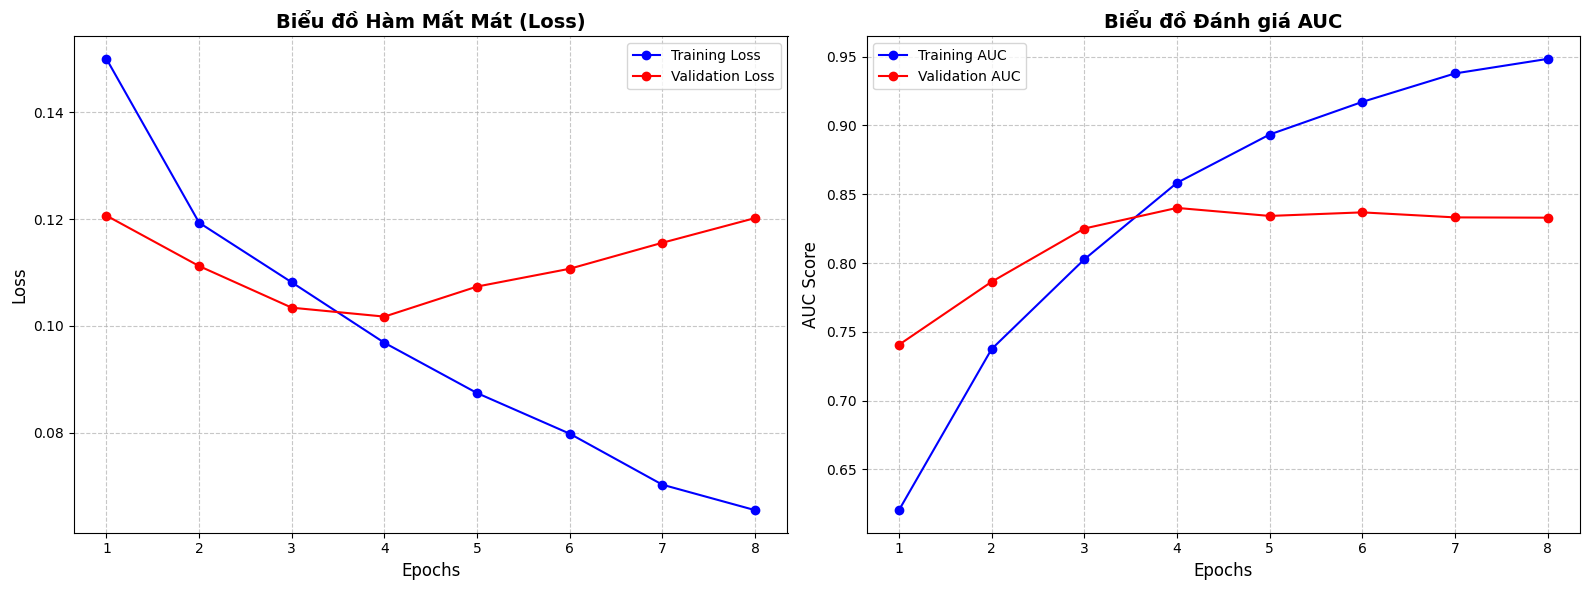

In [11]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    # Dùng .get() để lấy dữ liệu an toàn. Nếu không có sẽ trả về None thay vì báo lỗi.
    loss = history.history.get('loss')
    val_loss = history.history.get('val_loss')

    acc = history.history.get('accuracy')
    val_acc = history.history.get('val_accuracy')

    auc = history.history.get('auc')
    val_auc = history.history.get('val_auc')

    # Dùng chiều dài của mảng loss làm trục X (Epochs)
    epochs = range(1, len(loss) + 1)

    # Khởi tạo khung vẽ có 2 biểu đồ (Loss và Metric)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # --- Biểu đồ 1: Hàm Mất mát (Loss) ---
    if loss and val_loss:
        ax1.plot(epochs, loss, 'bo-', label='Training Loss')
        ax1.plot(epochs, val_loss, 'ro-', label='Validation Loss')
        ax1.set_title('Biểu đồ Hàm Mất Mát (Loss)', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Epochs', fontsize=12)
        ax1.set_ylabel('Loss', fontsize=12)
        ax1.legend()
        ax1.grid(True, linestyle='--', alpha=0.7)

    # --- Biểu đồ 2: Điểm AUC hoặc Accuracy ---
    # Ưu tiên vẽ AUC trước, nếu không có mới vẽ Accuracy
    if auc and val_auc:
        ax2.plot(epochs, auc, 'bo-', label='Training AUC')
        ax2.plot(epochs, val_auc, 'ro-', label='Validation AUC')
        ax2.set_title('Biểu đồ Đánh giá AUC', fontsize=14, fontweight='bold')
        ax2.set_ylabel('AUC Score', fontsize=12)
    elif acc and val_acc:
        ax2.plot(epochs, acc, 'bo-', label='Training Accuracy')
        ax2.plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
        ax2.set_title('Biểu đồ Đánh giá Độ chính xác (Accuracy)', fontsize=14, fontweight='bold')
        ax2.set_ylabel('Accuracy', fontsize=12)
    else:
        ax2.text(0.5, 0.5, 'Không có dữ liệu Metric', fontsize=12, ha='center')

    ax2.set_xlabel('Epochs', fontsize=12)
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

# Gọi hàm để vẽ đồ thị
plot_training_history(history)

📊 ĐANG VẼ BỘ MA TRẬN NHẦM LẪN ĐA NHÃN (MULTI-LABEL CONFUSION MATRIX)...
------------------------------------------------------------


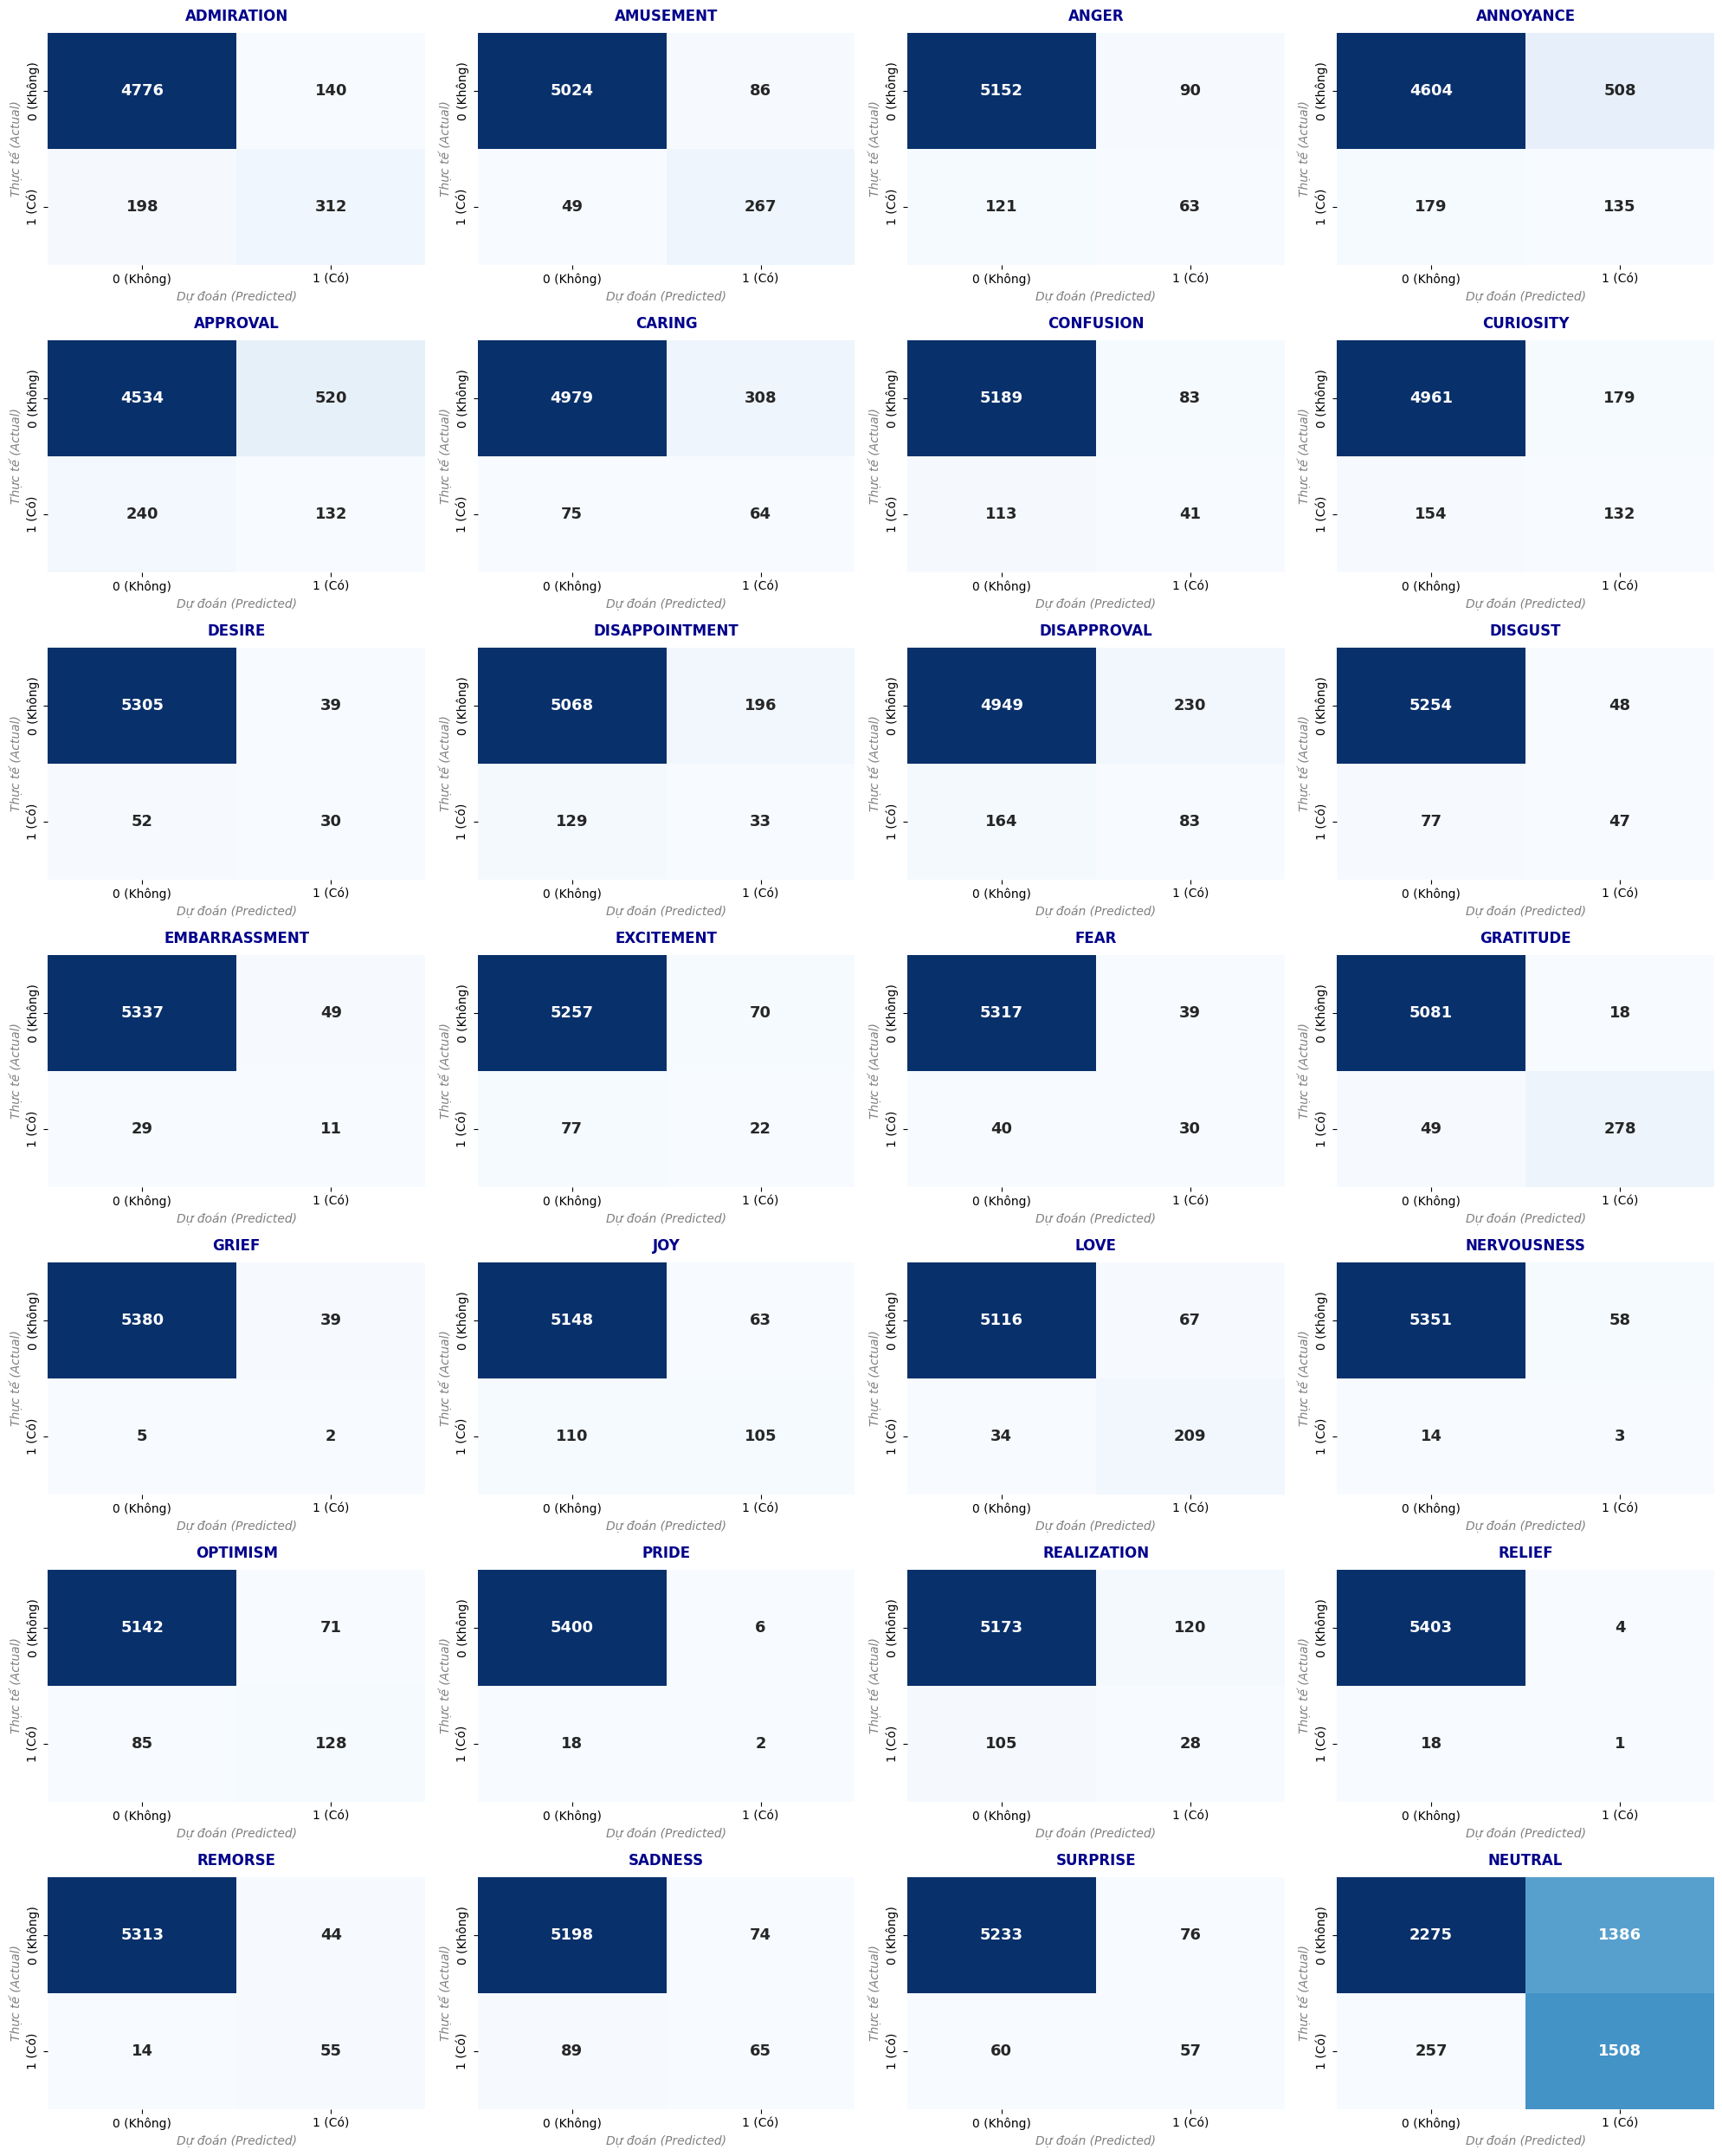

✅ Đã lưu đồ thị thành file 'MultiLabel_Confusion_Matrix.png' chất lượng cao!


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import multilabel_confusion_matrix

print("📊 ĐANG VẼ BỘ MA TRẬN NHẦM LẪN ĐA NHÃN (MULTI-LABEL CONFUSION MATRIX)...")
print("-" * 60)

# Ép kiểu an toàn (tránh lỗi nếu Y_test vẫn là Pandas DataFrame)
Y_test_array = Y_test.values if hasattr(Y_test, 'values') else Y_test

# Tính toán ma trận nhầm lẫn đa nhãn dựa trên kết quả tối ưu từ tập Test
# FIX TÊN BIẾN: Dùng Y_test_pred_binary đã tạo ở Cell trước
mcm = multilabel_confusion_matrix(Y_test_array, Y_test_pred_binary)

# Khởi tạo khung vẽ: 7 hàng, 4 cột để vừa khít 28 nhãn
fig, axes = plt.subplots(7, 4, figsize=(20, 25))
axes = axes.ravel()

for idx, label in enumerate(emotion_labels):
    ax = axes[idx]

    # Vẽ Heatmap cho từng nhãn
    sns.heatmap(
        mcm[idx],
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        xticklabels=['0 (Không)', '1 (Có)'],
        yticklabels=['0 (Không)', '1 (Có)'],
        ax=ax,
        annot_kws={"size": 13, "weight": "bold"}
    )

    # Trang trí tiêu đề và trục
    ax.set_title(f"{label.upper()}", fontsize=12, fontweight='bold', color='darkblue', pad=10)
    ax.set_xlabel("Dự đoán (Predicted)", fontsize=10, color='gray', style='italic')
    ax.set_ylabel("Thực tế (Actual)", fontsize=10, color='gray', style='italic')

# Căn chỉnh để các biểu đồ không bị đè chữ lên nhau
plt.tight_layout()
plt.show()

# LƯU TỰ ĐỘNG: Xuất ra ảnh nét căng để dán thẳng vào Word
fig.savefig('MultiLabel_Confusion_Matrix.png', dpi=300, bbox_inches='tight')
print("✅ Đã lưu đồ thị thành file 'MultiLabel_Confusion_Matrix.png' chất lượng cao!")

**Live test**

In [14]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("=== CỔNG THỰC NGHIỆM MÔ HÌNH 1D CNN + FASTTEXT ===")
print("Nhập một câu tiếng Anh bất kỳ để xem mô hình tính toán % xác suất độc lập.")
print("Gõ 'exit' hoặc 'thoat' để dừng chương trình.\n")

while True:
    user_input = input("✍️ Nhập bình luận tiếng Anh: ")

    if user_input.lower() in ['thoát', 'thoat', 'exit', 'quit']:
        print("👋 Đã đóng cổng thực nghiệm thành công!")
        break

    if user_input.strip() == "":
        continue

    # 1. Làm sạch văn bản đầu vào
    cleaned_input = clean_text_for_cnn(user_input, use_lemmatization=False)

    if cleaned_input == "":
        print("⚠️ Văn bản không hợp lệ sau khi làm sạch.")
        continue

    # 2. Chuyển đổi thành chuỗi số và padding
    seq = tokenizer.texts_to_sequences([cleaned_input])
    pad_seq = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')

    # 3. Dự đoán xác suất từ mô hình CNN đã huấn luyện
    # model_optimized trả về mảng xác suất cho 28 nhãn
    probs = model_optimized.predict(pad_seq, verbose=0)[0]

    print(f'\n📝 Câu gốc nhập vào : "{user_input}"')
    print(f'✨ Sau khi làm sạch  : "{cleaned_input}"')
    print("🤖 ĐỘ TỰ TIN XÁC SUẤT VÀ TRẠNG THÁI KÍCH HOẠT:")

    activated_any = False

    # 4. Duyệt qua từng nhãn để kiểm tra ngưỡng tối ưu (Threshold)
    for idx, score in enumerate(probs):
        label = emotion_labels[idx]
        current_thresh = best_thresholds[label]

        # Kiểm tra xem xác suất có vượt qua ngưỡng tối ưu của nhãn đó không
        if score >= current_thresh:
            print(f"   - [KÍCH HOẠT] {label.upper():>15}: {score * 100:>6.2f}% (Ngưỡng chuẩn: {current_thresh*100:.2f}%)")
            activated_any = True

    # 5. Cơ chế hiển thị nếu không nhãn nào vượt ngưỡng
    if not activated_any:
        top_idx = np.argmax(probs)
        top_score = probs[top_idx]
        top_label = emotion_labels[top_idx]

        if top_score > 0.10: # Nếu có nhãn gần đạt ngưỡng
            print(f"   - {top_label.upper():>15}: {top_score * 100:>6.2f}% (Sắc thái tiềm năng nhất - Chưa đạt ngưỡng kích hoạt)")
        else:
            # Lấy chỉ số của nhãn neutral
            n_idx = emotion_labels.index('neutral')
            print(f"   - NEUTRAL: {probs[n_idx] * 100:.2f}% (Trạng thái trung tính hoàn toàn)")

    print("-" * 70)

=== CỔNG THỰC NGHIỆM MÔ HÌNH 1D CNN + FASTTEXT ===
Nhập một câu tiếng Anh bất kỳ để xem mô hình tính toán % xác suất độc lập.
Gõ 'exit' hoặc 'thoat' để dừng chương trình.

✍️ Nhập bình luận tiếng Anh: "Good luck with your final exam tomorrow, you'll do great!"

📝 Câu gốc nhập vào : ""Good luck with your final exam tomorrow, you'll do great!""
✨ Sau khi làm sạch  : "good luck with your final exam tomorrow you will do great!"
🤖 ĐỘ TỰ TIN XÁC SUẤT VÀ TRẠNG THÁI KÍCH HOẠT:
   - [KÍCH HOẠT]      ADMIRATION:  67.07% (Ngưỡng chuẩn: 49.00%)
   - [KÍCH HOẠT]          CARING:  13.67% (Ngưỡng chuẩn: 7.00%)
   - [KÍCH HOẠT]        OPTIMISM:  33.87% (Ngưỡng chuẩn: 18.00%)
----------------------------------------------------------------------
✍️ Nhập bình luận tiếng Anh: "I laughed so hard at this that my ribs actually hurt."

📝 Câu gốc nhập vào : ""I laughed so hard at this that my ribs actually hurt.""
✨ Sau khi làm sạch  : "i laughed so hard at this that my ribs actually hurt"
🤖 ĐỘ TỰ TIN XÁC SUẤ

### 🔬 Deep Dive: Phân tích cơ chế hoạt động của 1D CNN trên một câu cụ thể
Đoạn code này giúp bạn hiểu mô hình thực sự 'đọc' câu văn như thế nào thông qua các lớp Embedding và Convolution.

In [15]:
import pandas as pd

def analyze_cnn_logic(sample_text):
    print(f"🔍 PHÂN TÍCH CHI TIẾT CÂU: '{sample_text}'\n")

    # 1. Quá trình tiền xử lý
    cleaned = clean_text_for_cnn(sample_text)
    tokens = cleaned.split()
    sequences = tokenizer.texts_to_sequences([cleaned])[0]
    padded = pad_sequences([sequences], maxlen=MAX_LEN, padding='post')[0]

    print(f"Step 1: Tokenization (Chuyển từ thành số)")
    token_map = {word: idx for word, idx in zip(tokens, sequences)}
    print(f"   - Các cặp Từ-Mã số: {token_map}")
    print(f"   - Dạng Vector đệm (Padding): {padded[:len(tokens)+2]}... (tổng 50 chiều)\n")

    print(f"Step 2: Cơ chế Multi-Kernel CNN")
    print(f"   - Kernel 2: Đang quét các cụm 2 từ (Bigrams) như: {[' '.join(tokens[i:i+2]) for i in range(len(tokens)-1)]}")
    print(f"   - Kernel 3: Đang quét các cụm 3 từ (Trigrams) như: {[' '.join(tokens[i:i+3]) for i in range(len(tokens)-2)]}")
    print(f"   - Kernel 4: Đang quét các cụm 4 từ (4-grams) như: {[' '.join(tokens[i:i+4]) for i in range(len(tokens)-3)]}")
    print("   => GlobalMaxPooling1D sẽ chọn ra 'tín hiệu' mạnh nhất từ các cụm từ này để quyết định cảm xúc.\n")

    # 2. Dự đoán
    probs = model_optimized.predict(pad_sequences([sequences], maxlen=MAX_LEN, padding='post'), verbose=0)[0]

    # 3. Tổng hợp kết quả 28 nhãn
    analysis_df = pd.DataFrame({
        'Cảm xúc': emotion_labels,
        'Xác suất (%)': [p * 100 for p in probs],
        'Ngưỡng cắt (%)': [best_thresholds[l] * 100 for l in emotion_labels]
    })
    analysis_df['Kích hoạt'] = analysis_df['Xác suất (%)'] >= analysis_df['Ngưỡng cắt (%)']
    analysis_df = analysis_df.sort_values(by='Xác suất (%)', ascending=False)

    print("Step 3: Bảng xếp hạng xác suất 28 nhãn")
    display(analysis_df.style.format({'Xác suất (%)': '{:.2f}', 'Ngưỡng cắt (%)': '{:.2f}'}))

# Chạy thử với 1 câu khó (pha trộn cảm xúc)
test_sentence = "I am a bit confused, but the result is surprisingly good!"
analyze_cnn_logic(test_sentence)

🔍 PHÂN TÍCH CHI TIẾT CÂU: 'I am a bit confused, but the result is surprisingly good!'

Step 1: Tokenization (Chuyển từ thành số)
   - Các cặp Từ-Mã số: {'i': 2, 'am': 25, 'a': 6, 'bit': 313, 'confused': 620, 'but': 22, 'the': 3, 'result': 1578, 'is': 4, 'surprisingly': 3798, 'good!': 47}
   - Dạng Vector đệm (Padding): [   2   25    6  313  620   22    3 1578    4 3798   47    0    0]... (tổng 50 chiều)

Step 2: Cơ chế Multi-Kernel CNN
   - Kernel 2: Đang quét các cụm 2 từ (Bigrams) như: ['i am', 'am a', 'a bit', 'bit confused', 'confused but', 'but the', 'the result', 'result is', 'is surprisingly', 'surprisingly good!']
   - Kernel 3: Đang quét các cụm 3 từ (Trigrams) như: ['i am a', 'am a bit', 'a bit confused', 'bit confused but', 'confused but the', 'but the result', 'the result is', 'result is surprisingly', 'is surprisingly good!']
   - Kernel 4: Đang quét các cụm 4 từ (4-grams) như: ['i am a bit', 'am a bit confused', 'a bit confused but', 'bit confused but the', 'confused but 

,Cảm xúc,Xác suất (%),Ngưỡng cắt (%),Kích hoạt
0,admiration,58.39,49.00,True
26,surprise,15.06,21.00,False
7,curiosity,11.87,23.00,False
6,confusion,7.97,21.00,False
1,amusement,3.81,39.00,False
4,approval,3.09,11.00,False
13,excitement,2.93,13.00,False
22,realization,2.52,8.00,False
27,neutral,1.66,18.00,False
15,gratitude,1.18,53.00,False


**test all**